


Göğüs kanseri, en kötü huylu kanser türlerinden biri olarak, dünyada
kadınların fiziksel ve zihinsel sağlığını ciddi şekilde tehdit
etmektedir. Ancak, erken evrede metastatik olmayan bir hastalık olarak
tespit edilirse tedavi edilebilir; bu nedenle erken tespitin önemi ve bu
alanda araştırma yapma ihtiyacı vurgulanmaktadır. Breast Cancer
Wisconsin (Tanısal) Veri Kümesi, böyle bir araştırma sürecinde Makine
Öğrenimi tekniklerini uygulama fırsatı sunmaktadır. Herhangi bir Makine
Öğrenimi algoritmasını dağıtmadan önce atılacak önemli bir adım, verilen
 veri kümesinin özelliklerini incelemek, genellikle Keşifsel Veri
 Analizi (EDA) olarak adlandırılır. Bu blog, temel Python kodu
 kullanarak bu veri kümesini detaylı bir şekilde anlamamıza yardımcı
 olacaktır.
 Bu veri kümesi ayrıca UCI Makine Öğrenimi Veri Setleri Arşivi'nden  indirilebilir.
 https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic




# 1. Veri kümesi ne zaman, hangi makale/çalışma kapsamında oluşturulmuştur?

Breast Cancer Wisconsin (Diagnostic) veri kümesi, 1995 yılında Dr. William H. Wolberg tarafından oluşturulmuştur. Veri kümesi, Wisconsin-Madison Üniversitesi'nde toplanan göğüs kanseri örneklerinden elde edilmiştir. Bu veri kümesi, hastaların özelliklerini (örneğin, tümörlerin boyutu ve şekli) içermekte ve bu özelliklere dayalı olarak hastaların malign (kötü huylu) veya benign (iyi huylu) olup olmadığını sınıflandırmak için kullanılmaktadır.

Elde edilen veriler, göğüs kanseri teşhisi için makine öğrenimi ve istatistiksel analizler uygulamak amacıyla yaygın bir şekilde kullanılmaktadır. Bunun yanı sıra, veri kümesi üzerinde yapılan çalışmalar ve makaleler, kanser teşhisi süreçlerini iyileştirmek ve erken teşhis yöntemlerini geliştirmek üzerine odaklanmaktadır.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
columns = [
    'ID', 'Diagnosis',
    'radius1', 'texture1', 'perimeter1', 'area1',
    'smoothness1', 'compactness1', 'concavity1', 'concave_points1',
    'symmetry1', 'fractal_dimension1', 'radius2', 'texture2',
    'perimeter2', 'area2', 'smoothness2', 'compactness2',
    'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2',
    'radius3', 'texture3', 'perimeter3', 'area3',
    'smoothness3', 'compactness3', 'concavity3',
    'concave_points3', 'symmetry3', 'fractal_dimension3'
]

# wdbc.data dosyasından veri yükleme
df = pd.read_csv('/wdbc.data', header=None, names=columns)

# Dataframe'in ilk birkaç satırını göster
print(df.head())

         ID Diagnosis  radius1  texture1  perimeter1   area1  smoothness1  \
0    842302         M    17.99     10.38      122.80  1001.0      0.11840   
1    842517         M    20.57     17.77      132.90  1326.0      0.08474   
2  84300903         M    19.69     21.25      130.00  1203.0      0.10960   
3  84348301         M    11.42     20.38       77.58   386.1      0.14250   
4  84358402         M    20.29     14.34      135.10  1297.0      0.10030   

   compactness1  concavity1  concave_points1  ...  radius3  texture3  \
0       0.27760      0.3001          0.14710  ...    25.38     17.33   
1       0.07864      0.0869          0.07017  ...    24.99     23.41   
2       0.15990      0.1974          0.12790  ...    23.57     25.53   
3       0.28390      0.2414          0.10520  ...    14.91     26.50   
4       0.13280      0.1980          0.10430  ...    22.54     16.67   

   perimeter3   area3  smoothness3  compactness3  concavity3  concave_points3  \
0      184.60  2019.0  

In [5]:
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

# 2. Veri kümesi kaç sınıftan oluşmaktadır?

In [6]:
# Veri kümesi kaç sınıftan oluşmaktadır?
class_distribution = df['Diagnosis'].value_counts()
print("Class distribution:")
print(class_distribution)
num_classes = class_distribution.count()
print(f"Number of classes: {num_classes}")

Class distribution:
Diagnosis
0    357
1    212
Name: count, dtype: int64
Number of classes: 2


Veri kümesi 2 sınıftan oluşmaktadır.

0.37258347978910367
Total number of data points =   569
Malignant (diagnosis =1) = 37.3%
Benign (diagnosis =0)= 62.7%


<Axes: title={'center': 'Malignant (1) vs Benign Data(0) points'}, xlabel='Diagnosis', ylabel='Number of data points'>

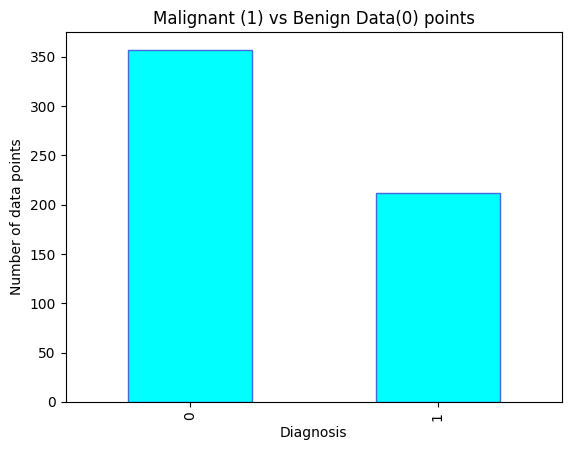

In [7]:
df["Diagnosis"].value_counts()
print(df["Diagnosis"].mean())#Plot the number of data points with mailgnant and benign as their diagnosis
print("Total number of data points =  ", len(df))
print("Malignant (diagnosis =1) = {}%".format(round(df["Diagnosis"].mean(),3)*100))

print("Benign (diagnosis =0)= {}%".format((1-round(df["Diagnosis"].mean(),3))*100))
df.groupby("Diagnosis")['ID'].count().plot.bar(ylabel = "Number of data points", title = "Malignant (1) vs Benign Data(0) points", color = 'cyan', edgecolor = "royalblue")

# 3. Veri kümesi dağılımı nasıldır? (dengeli/dengesiz)

In [8]:
# Veri kümesi dağılımı nasıldır? (dengeli/dengesiz)
print("Class distribution:")
print(class_distribution)

is_balanced = class_distribution.min() / class_distribution.max() > 0.5
print(f"Is the dataset balanced? {'Yes' if is_balanced else 'No'}")

Class distribution:
Diagnosis
0    357
1    212
Name: count, dtype: int64
Is the dataset balanced? Yes


Dağılımı dengelidir

# 4. Veri kümesi içerisinde kaç tane örnek yer almaktadır?

In [9]:
# Veri kümesi içerisinde kaç tane örnek yer almaktadır?
num_samples = df.shape[0]
print(f"Number of samples: {num_samples}")

Number of samples: 569


Veri kümesi 569 örnekten oluşmaktadır.

# 5. Veri kümesinde boş/eksik/yanlış değer var mı?

In [10]:
# Veri kümesinde boş/eksik/yanlış değer var mı?
missing_values = df.isnull().sum()


print("Missing values count in each column:")
for column, count in missing_values.items():
    print(f"{column}: {count}")

# bos/yanlis:
# invalid_counts = {}
# for column in df.columns[2:]:  # Skip ID and Diagnosis
#     invalid_counts[column] = df[~df[column].apply(lambda x: isinstance(x, (int, float)))].count()

# # Display invalid values count for each column
# print("\nYanlış Değerler:")
# for column, count in invalid_counts.items():
#     print(f"{column}: {count}")

Missing values count in each column:
ID: 0
Diagnosis: 0
radius1: 0
texture1: 0
perimeter1: 0
area1: 0
smoothness1: 0
compactness1: 0
concavity1: 0
concave_points1: 0
symmetry1: 0
fractal_dimension1: 0
radius2: 0
texture2: 0
perimeter2: 0
area2: 0
smoothness2: 0
compactness2: 0
concavity2: 0
concave_points2: 0
symmetry2: 0
fractal_dimension2: 0
radius3: 0
texture3: 0
perimeter3: 0
area3: 0
smoothness3: 0
compactness3: 0
concavity3: 0
concave_points3: 0
symmetry3: 0
fractal_dimension3: 0


Veri kümesinde boş değer yoktur.

# 6. Veri kümesinde kaç adet öznitelik vardır? Bu öznitelikler hangi yapıdadır?

In [11]:
# Veri kümesinde kaç adet öznitelik vardır? Bu öznitelikler hangi yapıdadır?

num_features = df.shape[1] - 2  #  ID ve Diagnosis haric
print(f"Number of features: {num_features}")
print("Data types of features:")
print(df.dtypes)

Number of features: 30
Data types of features:
ID                      int64
Diagnosis               int64
radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3       float64
symmetry3             float64
fractal_dimension3    f

Veri kümesinde 30 tane öznitelik vardır, yapısı float64'tür.

# 7. Veri kümesine ait temel istatistiksel özellikler nasıldır? Örneğin veri kümesi nümerik değerlerden oluşan bir veri kümesi ise sınıflar ile öznitelikler arasındaki korelasyon, özniteliklere ait standart sapma, ortalama, maksimum ve minimum değerler gibi


In [12]:
# Veri kümesine ait temel istatistiksel özellikler nasıldır? Örneğin veri kümesi nümerik değerlerden oluşan bir veri kümesi ise sınıflar ile öznitelikler arasındaki korelasyon, özniteliklere ait standart sapma, ortalama, maksimum ve minimum değerler gibi
statistics = df.describe()
print("Statistical summary of the dataset:")
print(statistics)

# Correlation with Diagnosis
correlations = df.corr()
print("Correlation with Diagnosis:")
print(correlations['Diagnosis'])

Statistical summary of the dataset:
                 ID   Diagnosis     radius1    texture1  perimeter1  \
count  5.690000e+02  569.000000  569.000000  569.000000  569.000000   
mean   3.037183e+07    0.372583   14.127292   19.289649   91.969033   
std    1.250206e+08    0.483918    3.524049    4.301036   24.298981   
min    8.670000e+03    0.000000    6.981000    9.710000   43.790000   
25%    8.692180e+05    0.000000   11.700000   16.170000   75.170000   
50%    9.060240e+05    0.000000   13.370000   18.840000   86.240000   
75%    8.813129e+06    1.000000   15.780000   21.800000  104.100000   
max    9.113205e+08    1.000000   28.110000   39.280000  188.500000   

             area1  smoothness1  compactness1  concavity1  concave_points1  \
count   569.000000   569.000000    569.000000  569.000000       569.000000   
mean    654.889104     0.096360      0.104341    0.088799         0.048919   
std     351.914129     0.014064      0.052813    0.079720         0.038803   
min     143.

# 8. 9. ve 12. Box Plot ve Violin Plot Grafikleri
Bu grafiklerin oluşturulması ve görselleştirilmesi için sklearn ve seaborn kütüphaneleri kullanılmaktadır.

<ipython-input-13-c9db8fc061f1>:34: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="variable", y="value", hue="Diagnosis",
<ipython-input-13-c9db8fc061f1>:40: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="variable", y="value", hue="Diagnosis",
<ipython-input-13-c9db8fc061f1>:46: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="variable", y="value", hue="Diagnosis",


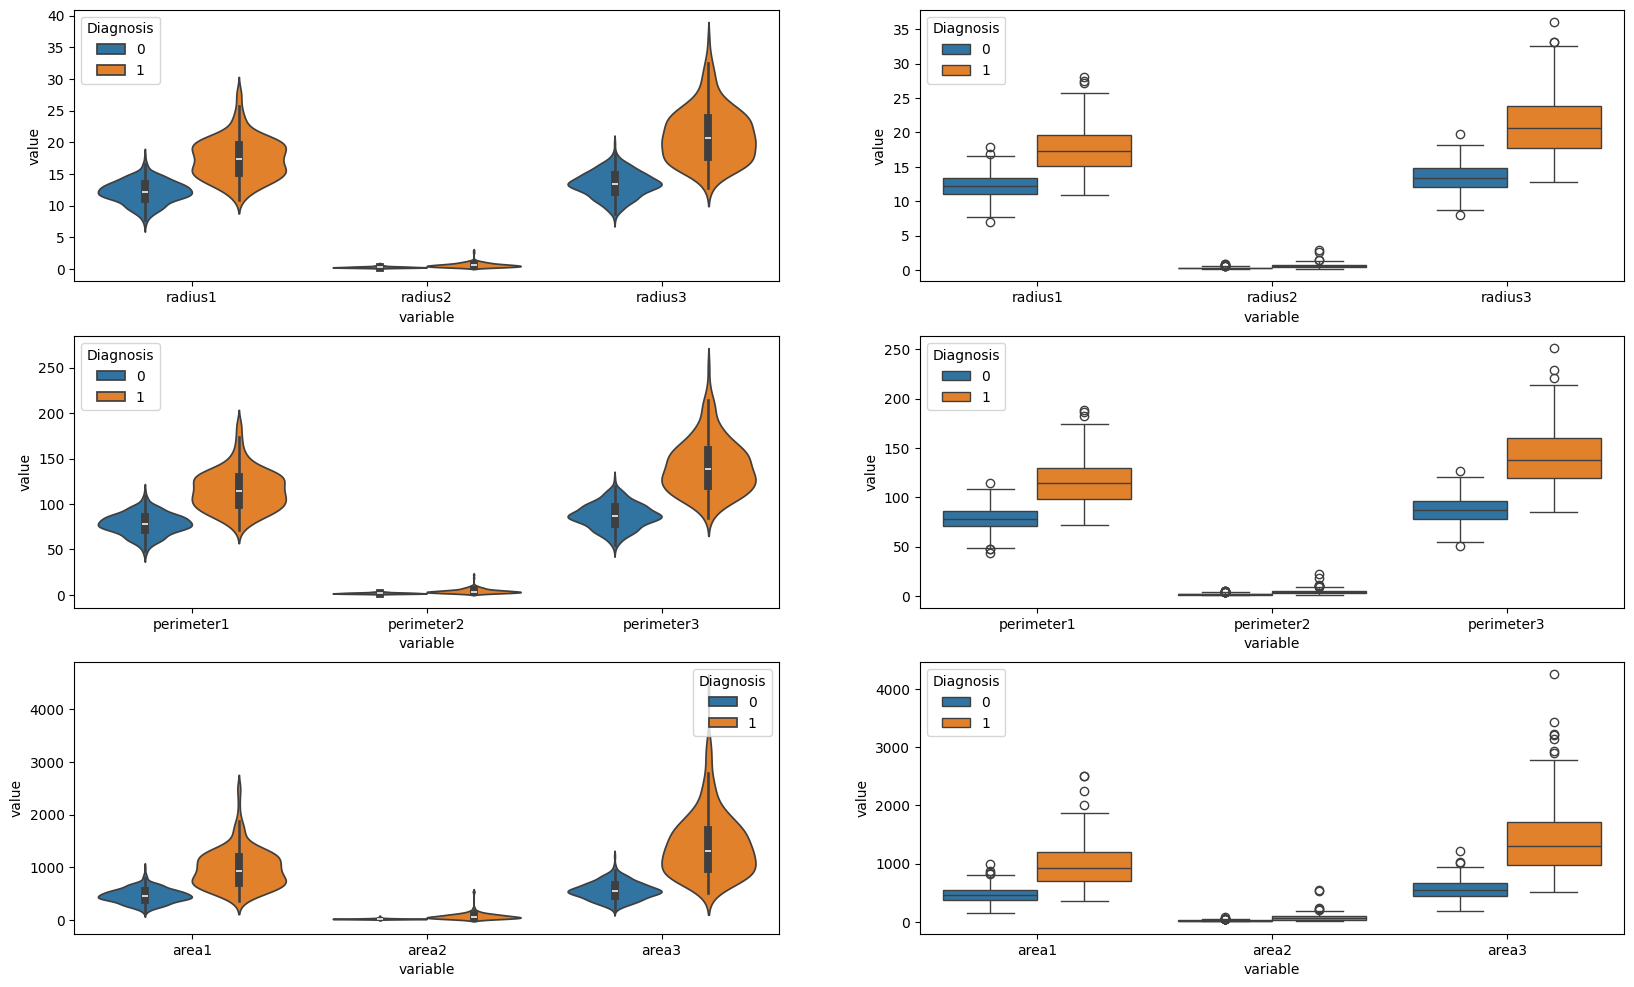

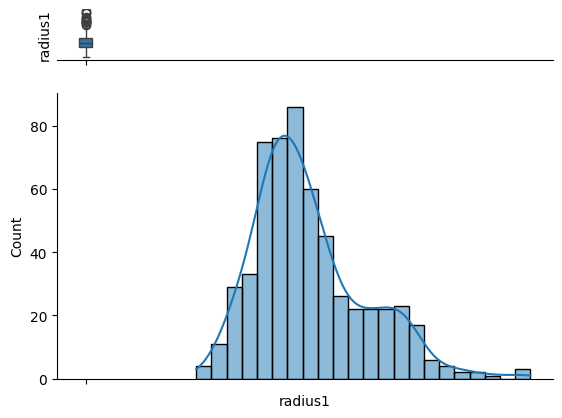

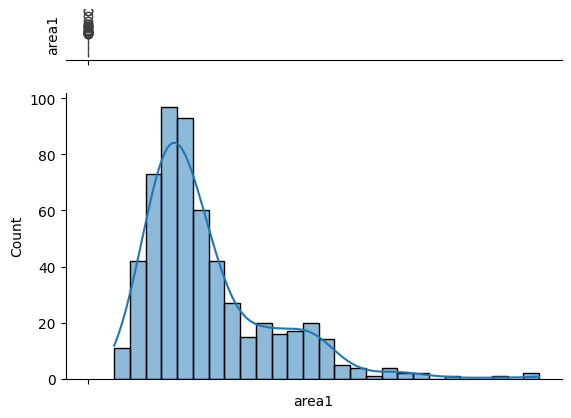

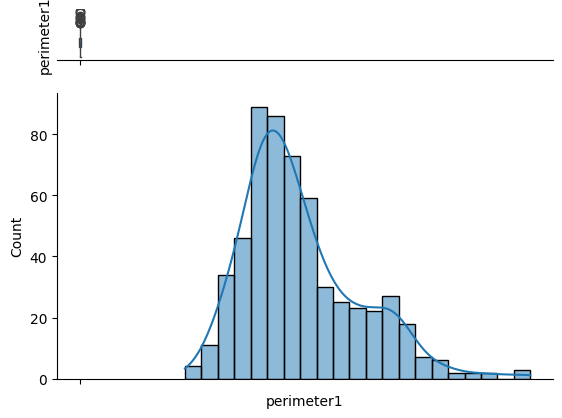

In [13]:
def get_box_dist_plot(data):
    """
    Generates a box plot and a distribution plot (distplot) for the given data.

    Parameters:
    data: Series or DataFrame column to plot.
    """
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (0.15, 0.85)})

    sns.boxplot(data, ax=ax_box)
    sns.histplot(data, kde=True, ax=ax_hist)  # Updated to use histplot instead of distplot

    ax_box.set(yticks=[])
    sns.despine(ax=ax_hist)
    sns.despine(ax=ax_box, left=True)

    plt.show()


# Define feature sets
columns_set_1 = ['Diagnosis', 'radius1', 'radius2', 'radius3']
df_set_1 = df[columns_set_1]

columns_set_2 = ['Diagnosis', 'perimeter1', 'perimeter2', 'perimeter3']
df_set_2 = df[columns_set_2]

columns_set_3 = ['Diagnosis', 'area1', 'area2', 'area3']
df_set_3 = df[columns_set_3]

# Create subplots for violin and box plots
fig, axs = plt.subplots(3, 2, figsize=(20, 12))

# Radius features
sns.violinplot(x="variable", y="value", hue="Diagnosis",
               data=pd.melt(df_set_1, id_vars='Diagnosis'), scale="width", ax=axs[0, 0])
sns.boxplot(x="variable", y="value", hue="Diagnosis",
            data=pd.melt(df_set_1, id_vars='Diagnosis'), ax=axs[0, 1])

# Perimeter features
sns.violinplot(x="variable", y="value", hue="Diagnosis",
               data=pd.melt(df_set_2, id_vars='Diagnosis'), scale="width", ax=axs[1, 0])
sns.boxplot(x="variable", y="value", hue="Diagnosis",
            data=pd.melt(df_set_2, id_vars='Diagnosis'), ax=axs[1, 1])

# Area features
sns.violinplot(x="variable", y="value", hue="Diagnosis",
               data=pd.melt(df_set_3, id_vars='Diagnosis'), scale="width", ax=axs[2, 0])
sns.boxplot(x="variable", y="value", hue="Diagnosis",
            data=pd.melt(df_set_3, id_vars='Diagnosis'), ax=axs[2, 1])

# Generate box and distribution plots for specific features
get_box_dist_plot(df["radius1"])
get_box_dist_plot(df["area1"])
get_box_dist_plot(df["perimeter1"])



**Gözlemler:**

- Benign (diagnosis = 0) ve malign (diagnosis = 1) veri noktaları için radius, perimeter ve area değerlerinde belirli bir ayrım seviyesi bulunmaktadır (bu, bir pairplot'un diyagonal grafiğinde de gözlemlenmiştir).
- Her bir öznitelikte, boxplot'ta gösterildiği gibi aykırı değerler görünmektedir ve bu nedenle veri ön işleme sürecinde ele alınması gerekmektedir.
- Dağılım, sağa çarpık bir Gauss dağılımı gibi görünmektedir.

<ipython-input-14-a96fb6ff5a75>:8: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="variable", y="value", hue="Diagnosis",


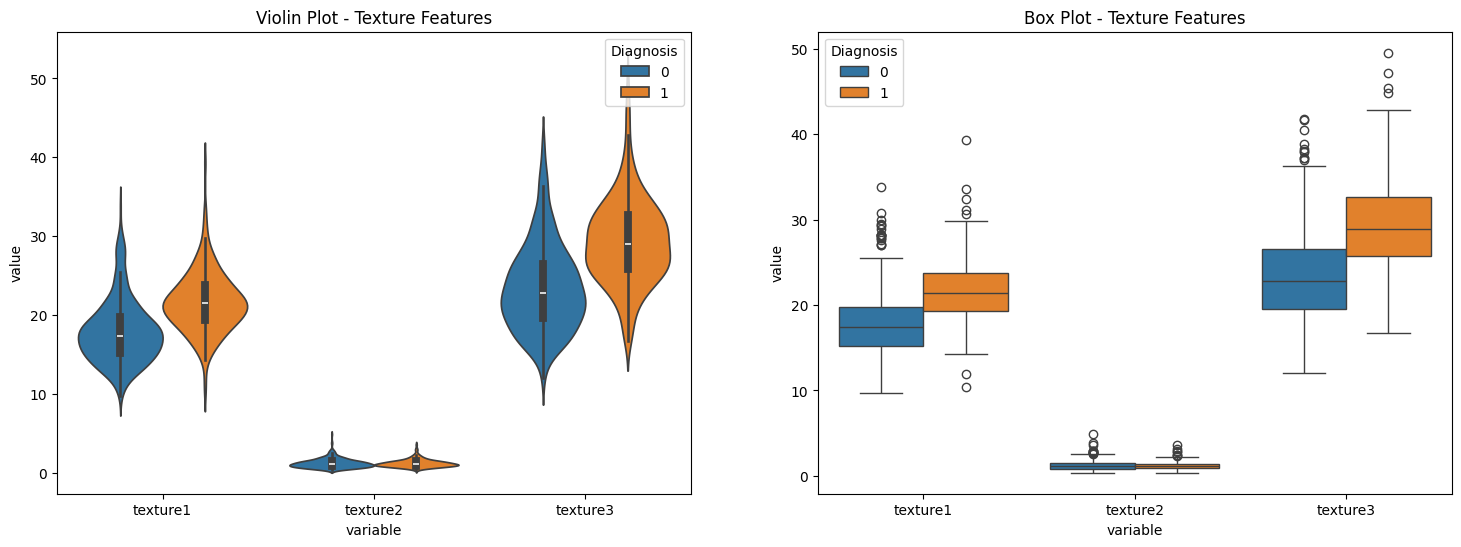

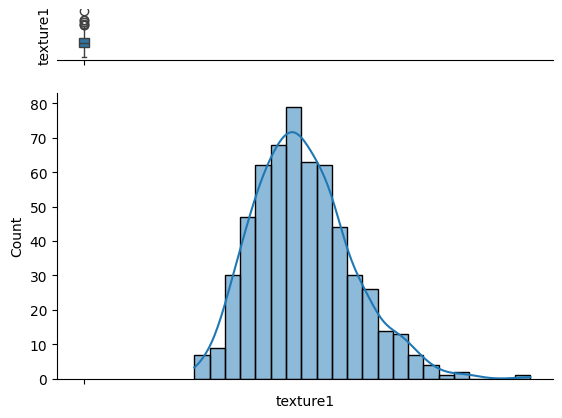

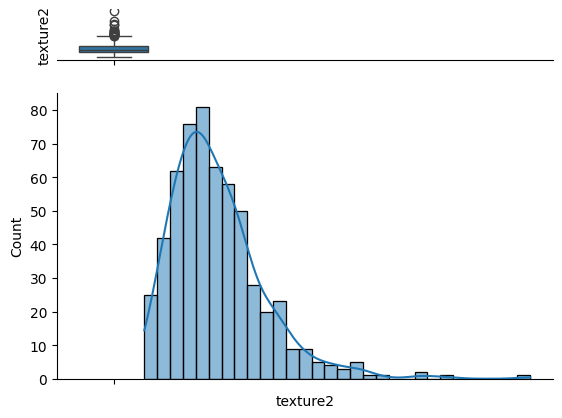

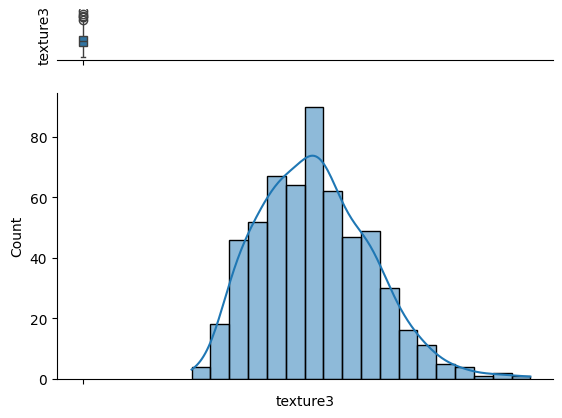

In [14]:
columns_set_4 = ['Diagnosis', 'texture1', 'texture2', 'texture3']
df_set_4 = pd.DataFrame(df, columns=columns_set_4)

# Create subplots for violin and box plots
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Violin plot for texture features
sns.violinplot(x="variable", y="value", hue="Diagnosis",
               data=pd.melt(df_set_4, id_vars='Diagnosis'), scale="width", ax=axs[0])
axs[0].set_title("Violin Plot - Texture Features")

# Box plot for texture features
sns.boxplot(x="variable", y="value", hue="Diagnosis",
            data=pd.melt(df_set_4, id_vars='Diagnosis'), ax=axs[1])
axs[1].set_title("Box Plot - Texture Features")

# Generate box and distribution plots for specific texture features
get_box_dist_plot(df["texture1"])
get_box_dist_plot(df["texture2"])
get_box_dist_plot(df["texture3"])

**Gözlemler:**

- Texture2 değerleri, hem malign hem de benign veri noktaları için aynı aralıkta yer almaktadır.
- Benign ve malign veri noktalarında texture1 ve texture3 arasında net bir ayrım görülmektedir.
- Üçü de aykırı değerler içermektedir (veri ön işleme aşamasında ele alınması gerekmektedir).
- Texture1 için dağılımın bir Gauss dağılımı gibi göründüğü söylenebilir. Texture2 ve texture3 için de benzer çıkarımlar yapılabilir (şu anda burada gösterilmeyen görüntüler).

<ipython-input-193-9a0f11382e43>:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="variable", y="value", hue="Diagnosis",


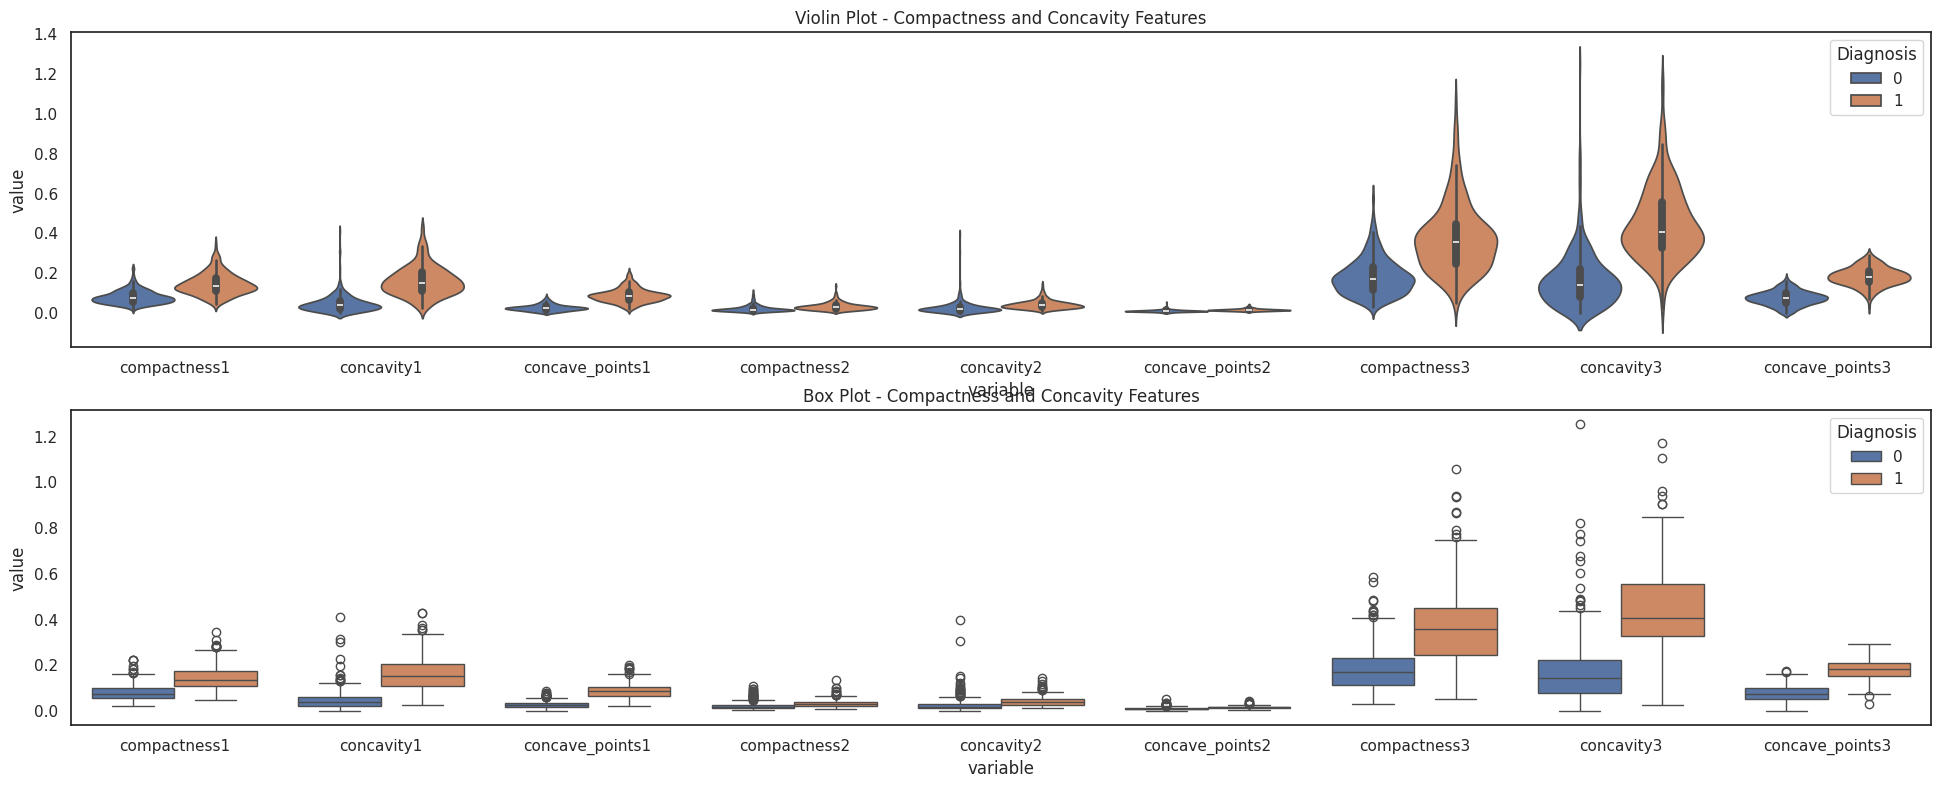

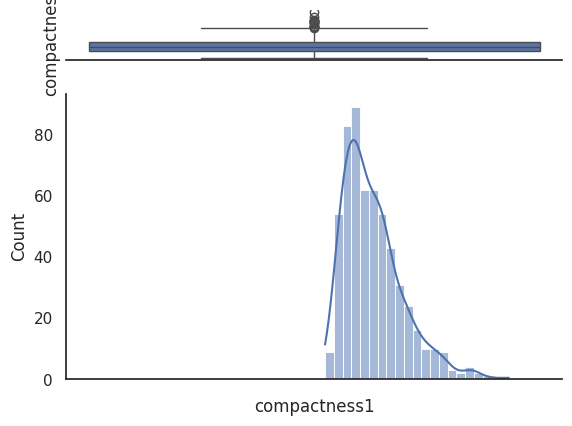

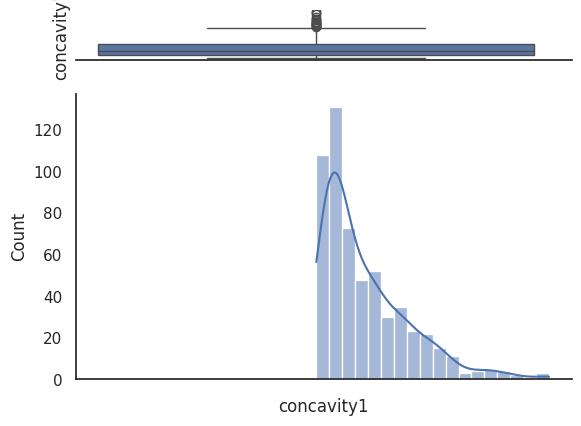

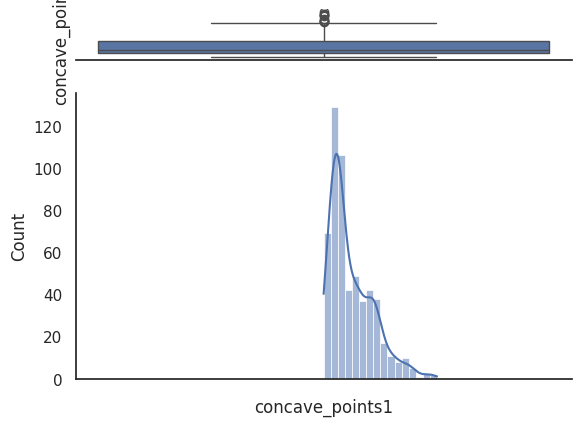

In [193]:
# Define the compactness and concavity feature set
columns_set_5 = ['Diagnosis', 'compactness1', 'concavity1', 'concave_points1',
                  'compactness2', 'concavity2', 'concave_points2',
                  'compactness3', 'concavity3', 'concave_points3']
df_set_5 = pd.DataFrame(df, columns=columns_set_5)

# Create subplots for violin and box plots
fig, axs = plt.subplots(2, figsize=(24, 9))

# Violin plot for compactness and concavity features
sns.violinplot(x="variable", y="value", hue="Diagnosis",
               data=pd.melt(df_set_5, id_vars='Diagnosis'), scale="width", ax=axs[0])
axs[0].set_title("Violin Plot - Compactness and Concavity Features")

# Box plot for compactness and concavity features
sns.boxplot(x="variable", y="value", hue="Diagnosis",
            data=pd.melt(df_set_5, id_vars='Diagnosis'), ax=axs[1])
axs[1].set_title("Box Plot - Compactness and Concavity Features")

# Generate box and distribution plots for specific features
get_box_dist_plot(df["compactness1"])
get_box_dist_plot(df["concavity1"])
get_box_dist_plot(df["concave_points1"])

**Gözlemler:**

- Yukarıdaki her bir öznitelikte belirli bir ayrım seviyesi bulunmaktadır.
- Aykırı değerler, boxplot'ta gösterildiği gibi bu özniteliklerin her birinde mevcuttur ve bu nedenle veri ön işleme sürecinde ele alınması gerekmektedir.
- Dağılım, sağa çarpık bir Gauss eğrisi gibi görünmektedir.

<ipython-input-15-565468e6c9dd>:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="variable", y="value", hue="Diagnosis",


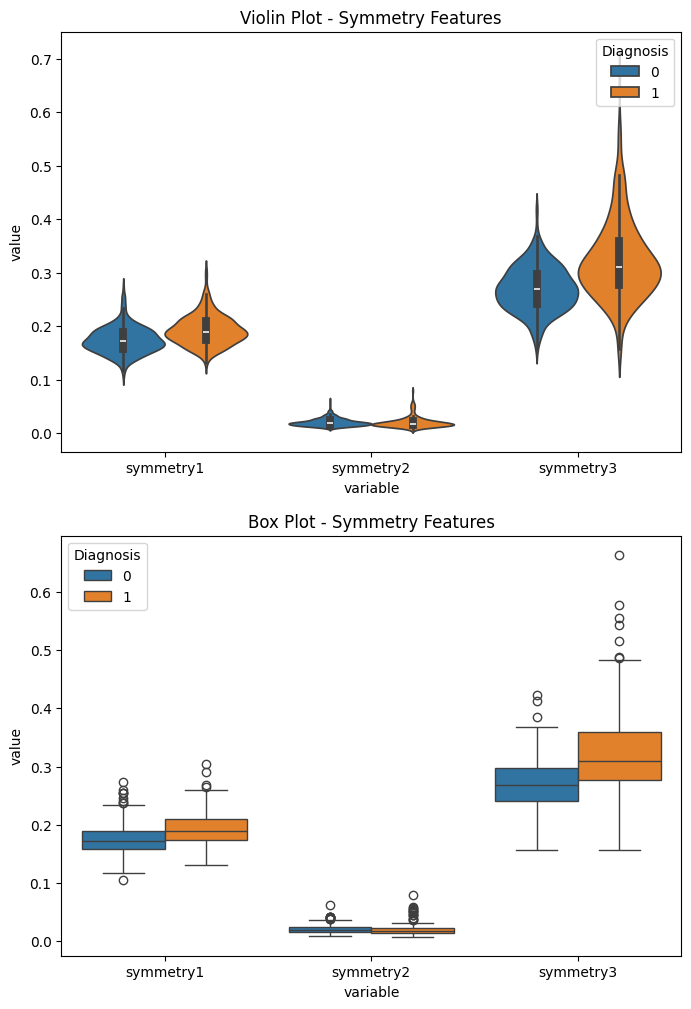

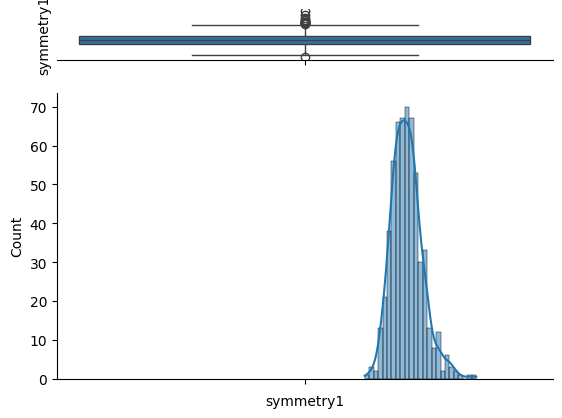

In [15]:
# Define the symmetry feature set
columns_set_6 = ['Diagnosis', 'symmetry1', 'symmetry2', 'symmetry3']
df_set_6 = pd.DataFrame(df, columns=columns_set_6)

# Create subplots for violin and box plots
fig, axs = plt.subplots(2, figsize=(8, 12))

# Violin plot for symmetry features
sns.violinplot(x="variable", y="value", hue="Diagnosis",
               data=pd.melt(df_set_6, id_vars='Diagnosis'), scale="width", ax=axs[0])
axs[0].set_title("Violin Plot - Symmetry Features")

# Box plot for symmetry features
sns.boxplot(x="variable", y="value", hue="Diagnosis",
            data=pd.melt(df_set_6, id_vars='Diagnosis'), ax=axs[1])
axs[1].set_title("Box Plot - Symmetry Features")

# Generate box and distribution plots for specific symmetry features
get_box_dist_plot(df["symmetry1"])

**Gözlemler:**

- Symmetry2 değerleri, hem malign hem de benign veri noktaları için aynı aralıkta yer almaktadır.
- Benign ve malign veri noktalarında symmetry1 ve symmetry3 arasında net bir ayrım görülmektedir.
- Üçünde de aykırı değerler bulunmaktadır (veri ön işleme aşamasında ele alınması gerekmektedir).
- Symmetry1 için, bir Gauss eğrisi gibi görünmektedir. Symmetry2 ve symmetry3 için de benzer çıkarımlar yapılabilir (şu anda burada gösterilmeyen görüntüler).

# 10. ve 11. Scatter plot grafikler ile veri kümesinin dağılımı ve görselleştirilmesi bunlara ait yorumlar ve değerlendirmeler


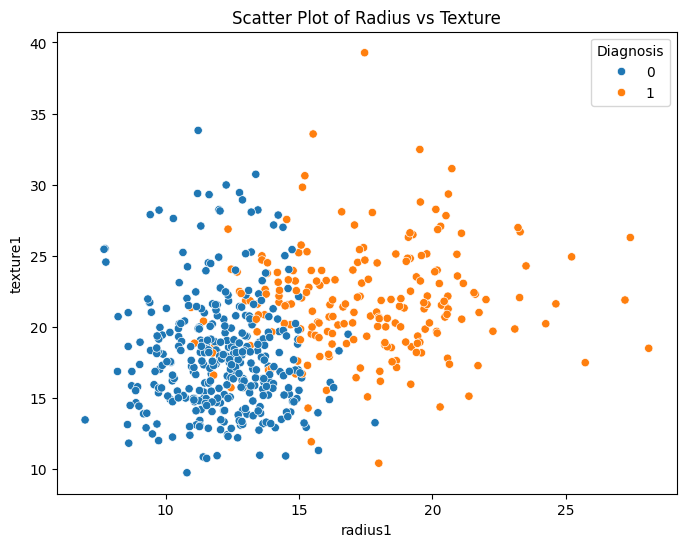

In [18]:
# Scatter plot grafikler ile veri kümesinin dağılımı ve görselleştirilmesi bunlara ait yorumlar ve değerlendirmeler

plt.figure(figsize=(8, 6))
sns.scatterplot(x='radius1', y='texture1', hue='Diagnosis', data=df)
plt.title('Scatter Plot of Radius vs Texture')
plt.show()

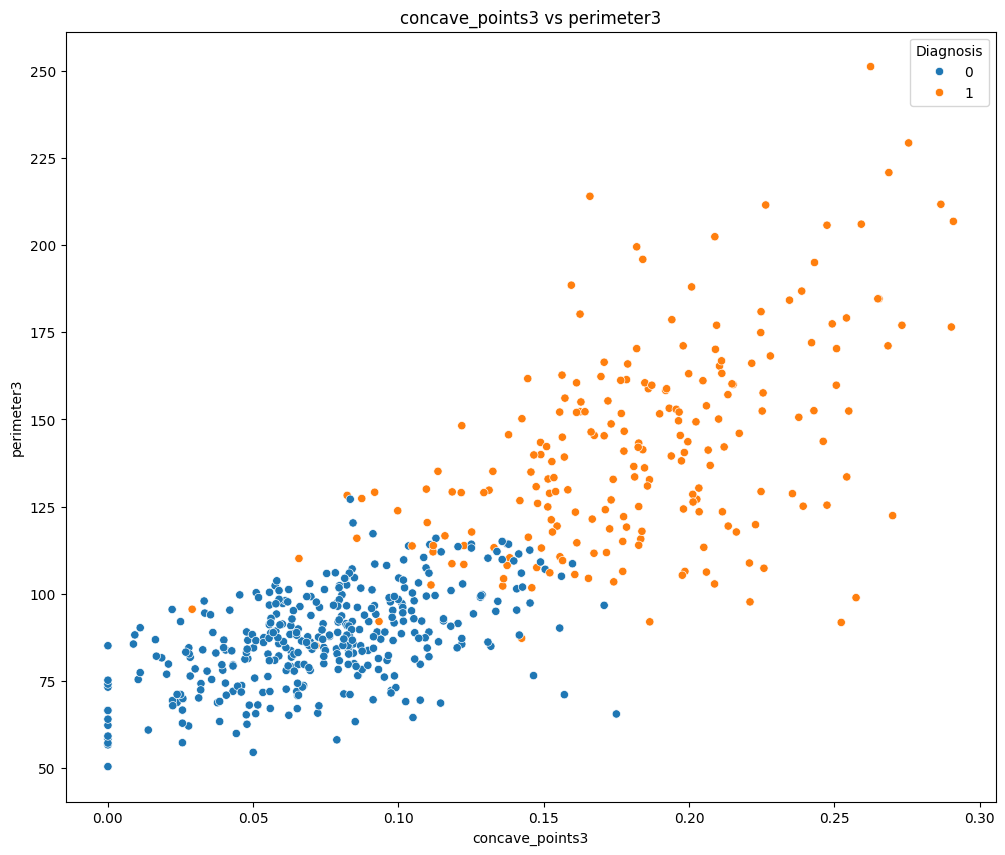

In [36]:
plt.figure(figsize=(12, 10))
sns.scatterplot(x='concave_points3', y='perimeter3', hue='Diagnosis', data=df)
plt.title('concave_points3 vs perimeter3')
plt.show()

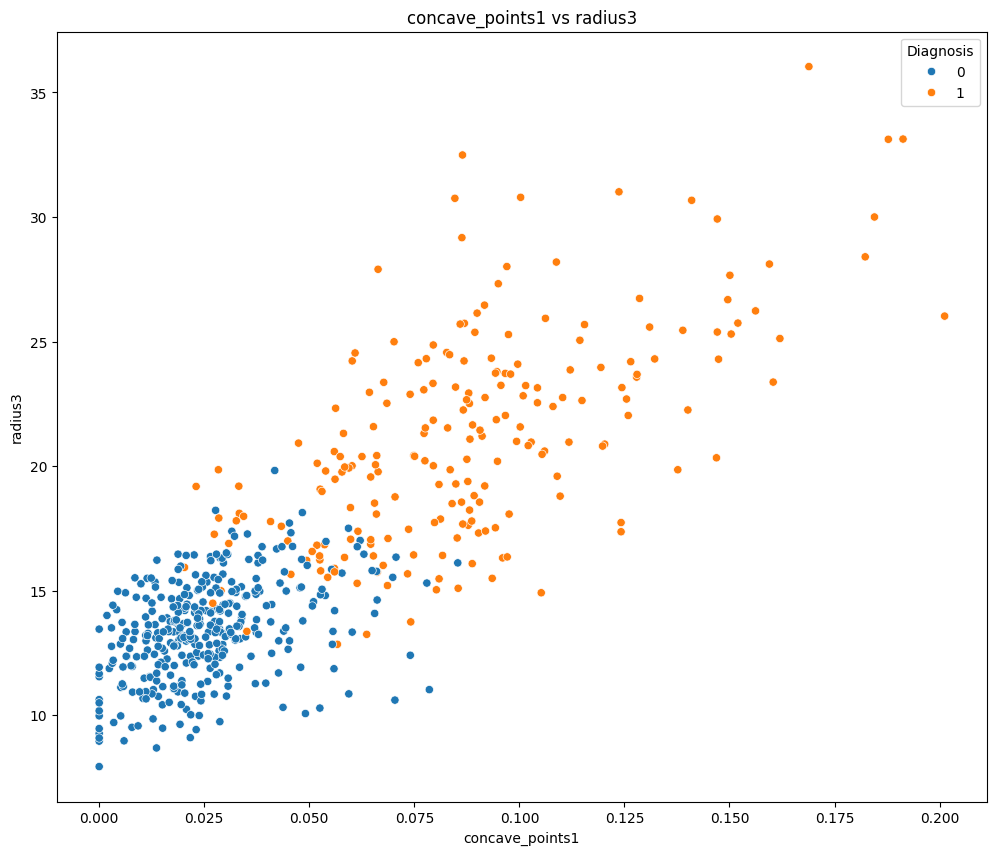

In [37]:
plt.figure(figsize=(12, 10))
sns.scatterplot(x='concave_points1', y='radius3', hue='Diagnosis', data=df)
plt.title('concave_points1 vs radius3')
plt.show()

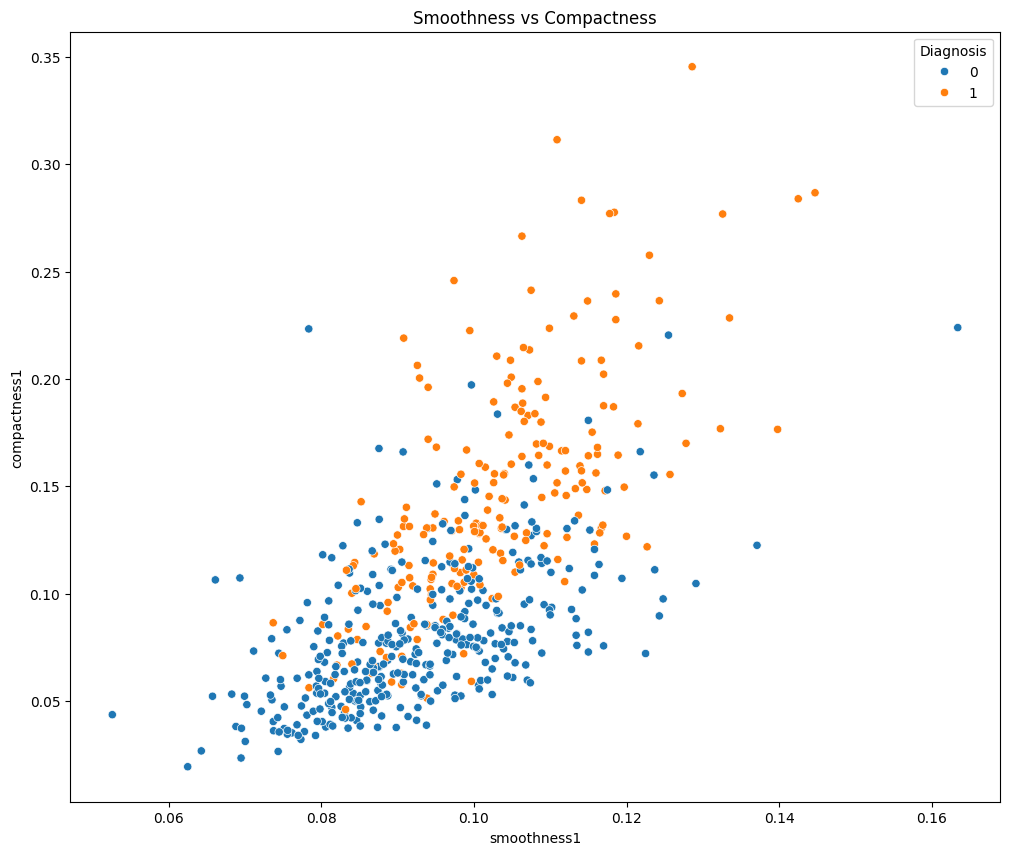

In [19]:
plt.figure(figsize=(12, 10))
sns.scatterplot(x='smoothness1', y='compactness1', hue='Diagnosis', data=df)
plt.title('Smoothness vs Compactness')
plt.show()

# 13. KNN ile Sınıflandırma

Bu kodlar, veri kümesindeki özellikler ile tanı durumu arasındaki ilişkileri anlamak için kullanılır. İlk olarak, 'ID' ve 'Diagnosis' sütunları dışındaki tüm sütunlar, özellikler olarak belirlenir. Sonrasında, Diagnosis ile olan korelasyonları görselleştirmek için bir heatmap oluşturulur. Bu heatmap, özelliklerin hedef değişkenle olan ilişkilerini daha iyi anlamaya yardımcı olur. En sonunda, Diagnosis ile en yüksek mutlak korelasyona sahip 10 özellik seçilir ve bu özellikler ekrana yazdırılır.

In [22]:

X = df.drop(['ID', 'Diagnosis'], axis=1)
y = df['Diagnosis']

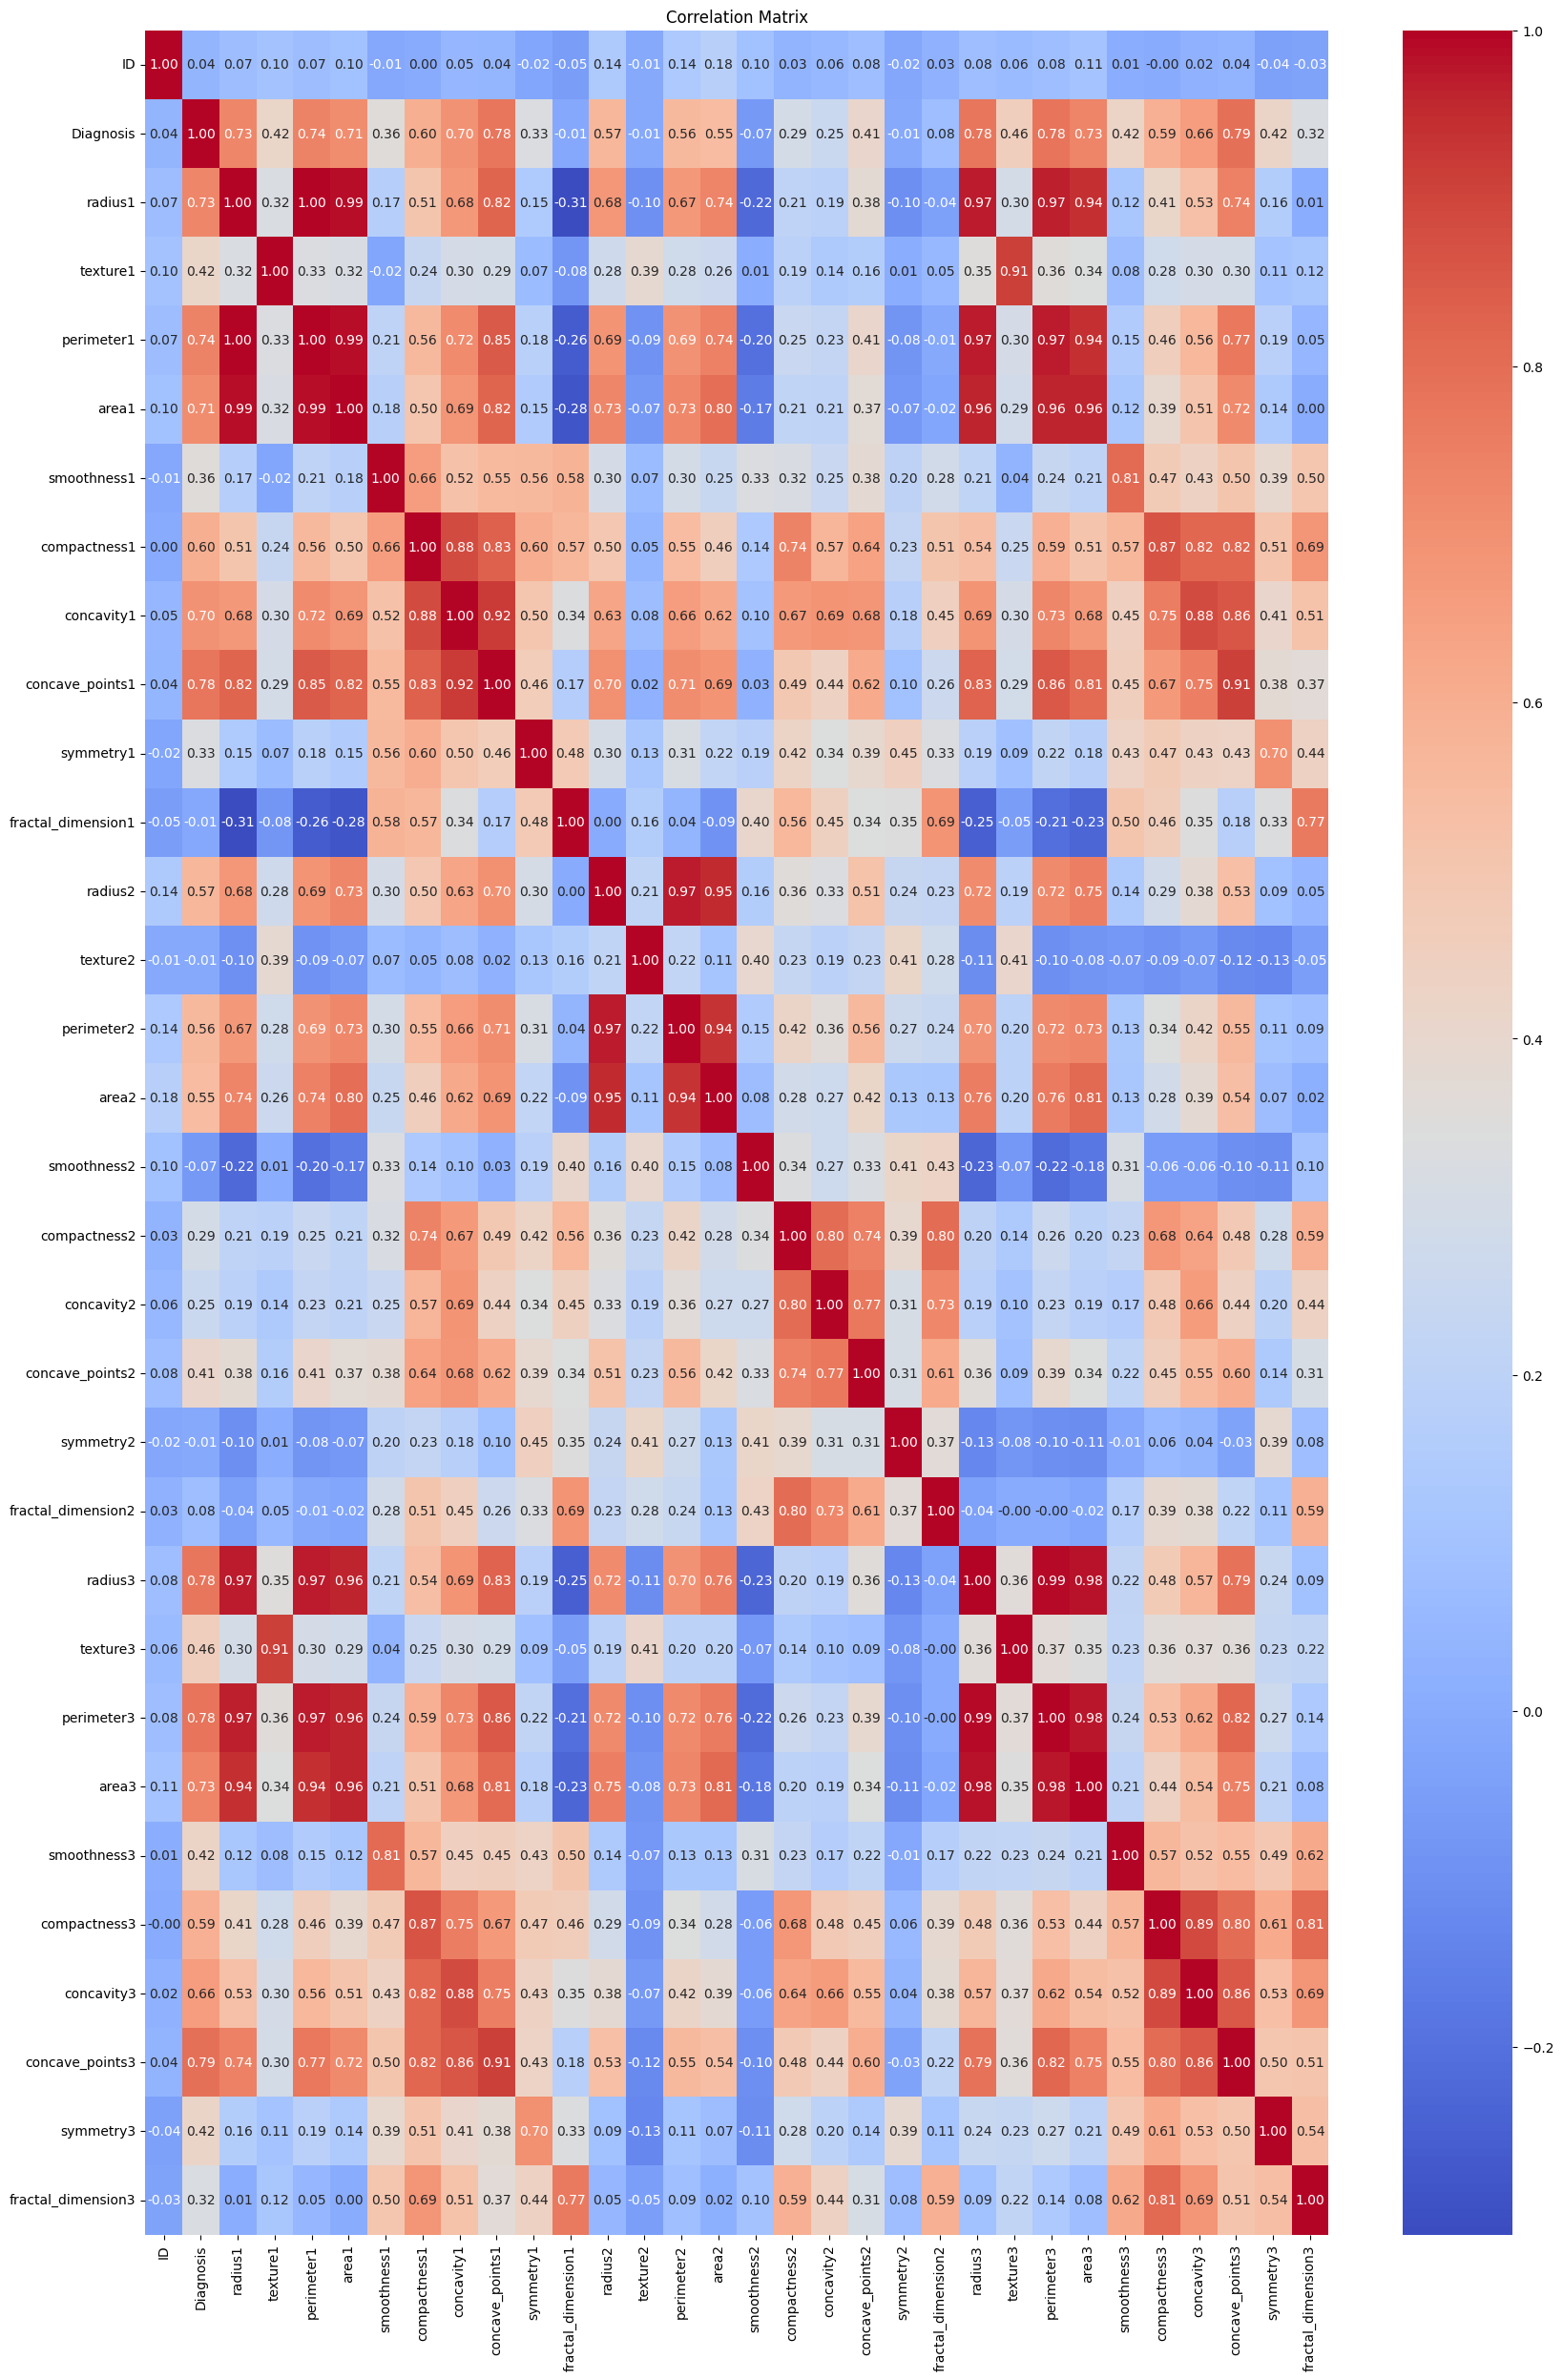

In [23]:
#  Korelasyon matrisinin görselleştirilmesi için bir heatmap oluşturma.
plt.figure(figsize=(20, 30))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [24]:
# Diagnosis ile en yüksek mutlak korelasyona sahip ilk 10 özelliği seçme.
selected_features = correlations['Diagnosis'].abs().sort_values(ascending=False).head(10)
print("Top features correlated with the diagnosis:")
print(selected_features)

Top features correlated with the diagnosis:
Diagnosis          1.000000
concave_points3    0.793566
perimeter3         0.782914
concave_points1    0.776614
radius3            0.776454
perimeter1         0.742636
area3              0.733825
radius1            0.730029
area1              0.708984
concavity1         0.696360
Name: Diagnosis, dtype: float64


Bu kodlar, makine öğrenimi modelinin daha etkili çalışabilmesi için verilerin hazırlanmasını sağlar. İlk olarak, belirli özellik isimlerini içeren bir liste tanımlanır. Ardından, bu özellikler veri çerçevesinden seçilir.

Sonraki adımda, verinin eğitim ve test setlerine ayrılması gerçekleştirilir; burada verinin %20'si test seti olarak ayrılır.

Son olarak, verilerin standartlaştırılması işlemi yapılır. Bu işlem, her bir özelliğin ortalamasını 0 ve standart sapmasını 1 olacak şekilde dönüştürür. Eğitim seti üzerinde fit işlemi yapılırken, test seti yalnızca dönüştürülür. Bu, modelin genel performansını artırmak için önemli bir adımdır.

In [28]:
selected_feature_names = [
    'concave_points3', 'perimeter3', 'concave_points1', 'radius3',
    'perimeter1', 'area3', 'radius1',
    'area1', 'concavity1'
]
X = df[selected_feature_names]

In [29]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [30]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Bu kod parçaları, K-en yakın komşu (KNN) sınıflandırma algoritmasını kullanarak bir makine öğrenimi modeli oluşturmayı ve değerlendirmenin sonuçlarını göstermeyi sağlar.

1. **KNN Sınıflandırıcı Tanımlama**: `KNeighborsClassifier(n_neighbors=5)` ifadesiyle KNN sınıflandırıcısı oluşturulur. Burada `n_neighbors` parametresi, sınıflandırmada kullanılacak en yakın 5 komşuyu belirtir.

2. **Modeli Eğitme**: `knn.fit(X_train_scaled, y_train)` ifadesi, standartlaştırılmış eğitim verisi ile modelin eğitilmesini sağlar. Bu aşamada model, giriş verilerini (özellikleri) ve bunlara karşılık gelen hedef değişkenleri (etiketler) öğrenir.

3. **Tahmin Yapma**: `y_pred = knn.predict(X_test_scaled)` ifadesi, eğitim aşamasında öğrenilen bilgileri kullanarak test setindeki veriler için tahminlerde bulunur.

4. **Modelin Değerlendirilmesi**:
   - `confusion_matrix(y_test, y_pred)` fonksiyonu, gerçek değerler ile tahmin edilen değerler arasındaki karşılaştırmayı yaparak bir karışıklık matrisi oluşturur. Bu matris, modelin hangi sınıfları doğru veya yanlış tahmin ettiğini gösterir.
   - `classification_report(y_test, y_pred)` fonksiyonu ise modelin performansını daha ayrıntılı bir şekilde değerlendirir. Bu rapor, doğruluk, geri çağırma, F1 skoru gibi metrikleri içerir ve modelin başarısını analiz etmeye yardımcı olur.

In [31]:
# KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [32]:

# Make predictions
y_pred = knn.predict(X_test_scaled)

In [34]:
# Evaluation
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Confusion Matrix:
[[69  2]
 [ 2 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



# Sadece concave_points3 ve perimeter3'i kullanarak Sınıflandırma

In [38]:
# concave_points3 perimeter3

selected_feature_names = [
    'concave_points3', 'perimeter3'
]
X = df[selected_feature_names]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)



In [42]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[68  3]
 [ 4 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        71
           1       0.93      0.91      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

